In [85]:
import numpy as np
import scipy
import scipy.sparse as sp
import time
import pickle

print("NumPy version:", np.__version__)
print("SciPy version:", scipy.__version__)

NumPy version: 2.4.3
SciPy version: 1.17.1


In [86]:
import pickle

with open("../solver_handoff.pkl", "rb") as f:
    solver_input = pickle.load(f)

print("MILP handoff loaded successfully!")
print(type(solver_input))
print(solver_input.keys())

MILP handoff loaded successfully!
<class 'dict'>
dict_keys(['A', 'constraint_lower', 'constraint_upper', 'objective', 'variable_lower', 'variable_upper', 'variable_integrality', 'n_variables', 'n_constraints', 'nnz', 'flight_variables', 'aircraft_variables', 'crew_variables', 'aircraft_arc_variables', 'constraint_rows'])


In [87]:
import os

print("Current working directory:")
print(os.getcwd())

print("\nFiles in current directory:")
print(os.listdir())

Current working directory:
c:\Users\Manya Aggarwal\ApexCUDA\notebooks

Files in current directory:
['ADMM_SOLVER_1000.ipynb', 'ApexCUDA_Updated_Sparse_MILP_GPU.ipynb', 'PRESOLVER_1000.ipynb']


In [88]:
import sys
import os

project_root = os.path.abspath("..")

if project_root not in sys.path:
    sys.path.insert(0, project_root)

print("Project root:", project_root)
print("backend available:", os.path.exists(os.path.join(project_root, "backend")))

Project root: c:\Users\Manya Aggarwal\ApexCUDA
backend available: True


In [89]:
import importlib
import backend.optimization_model as optimization_model

importlib.reload(optimization_model)

OptimizationModel = optimization_model.OptimizationModel
OptimizationResult = optimization_model.OptimizationResult

print("OptimizationResult loaded successfully")

OptimizationResult loaded successfully


In [90]:
from backend.optimization_model import OptimizationModel, OptimizationResult

model = OptimizationModel(
    A=solver_input["A"],
    constraint_lower=solver_input["constraint_lower"],
    constraint_upper=solver_input["constraint_upper"],
    objective=solver_input["objective"],
    variable_lower=solver_input["variable_lower"],
    variable_upper=solver_input["variable_upper"],
    variable_integrality=solver_input["variable_integrality"]
)

print("OptimizationModel reconstructed successfully")
print("Variables:", model.n_variables)
print("Constraints:", model.n_constraints)
print("Non-zeros:", model.nnz)
print("Problem type:", model.problem_type)
print(OptimizationResult)

OptimizationModel reconstructed successfully
Variables: 472798
Constraints: 3443145
Non-zeros: 7898666
Problem type: MILP
<class 'backend.optimization_model.OptimizationResult'>


In [91]:
A = solver_input["A"]

constraint_lower = solver_input["constraint_lower"]
constraint_upper = solver_input["constraint_upper"]

c = solver_input["objective"]

variable_lower = solver_input["variable_lower"]
variable_upper = solver_input["variable_upper"]

variable_integrality = solver_input["variable_integrality"]

print("All MILP objects extracted successfully.")

All MILP objects extracted successfully.


In [92]:
print("Matrix type:", type(A))
print("Matrix format:", A.format)
print("Matrix shape:", A.shape)
print("Number of nonzeros:", A.nnz)

Matrix type: <class 'scipy.sparse._csr.csr_matrix'>
Matrix format: csr
Matrix shape: (3443145, 472798)
Number of nonzeros: 7898666


In [93]:
print("Number of variables:", len(c))
print("Number of constraints:", A.shape[0])

print("Constraint lower:", len(constraint_lower))
print("Constraint upper:", len(constraint_upper))

print("Variable lower:", len(variable_lower))
print("Variable upper:", len(variable_upper))
print("Integrality:", len(variable_integrality))
assert A.shape[1] == len(c)
assert A.shape[0] == len(constraint_lower)
assert A.shape[0] == len(constraint_upper)

assert len(c) == len(variable_lower)
assert len(c) == len(variable_upper)
assert len(c) == len(variable_integrality)

print("\n✓ ALL DIMENSIONS MATCH")

Number of variables: 472798
Number of constraints: 3443145
Constraint lower: 3443145
Constraint upper: 3443145
Variable lower: 472798
Variable upper: 472798
Integrality: 472798

✓ ALL DIMENSIONS MATCH


In [94]:
integer_variables = np.sum(variable_integrality != 0)
continuous_variables = np.sum(variable_integrality == 0)

print("Integer/Binary variables:", integer_variables)
print("Continuous variables:", continuous_variables)

Integer/Binary variables: 472009
Continuous variables: 789


In [95]:
print("Variable lower bound range:")
print(np.min(variable_lower), "to", np.max(variable_lower))

print("\nVariable upper bound range:")
print(np.min(variable_upper), "to", np.max(variable_upper))

Variable lower bound range:
0.0 to 120.0

Variable upper bound range:
1.0 to 180.0


In [96]:
x_test = np.zeros(A.shape[1], dtype=np.float64)

start = time.perf_counter()

Ax = A @ x_test

elapsed = time.perf_counter() - start

print("Ax shape:", Ax.shape)
print("Time:", elapsed, "seconds")

Ax shape: (3443145,)
Time: 0.049811000004410744 seconds


In [97]:
y_test = np.zeros(A.shape[0], dtype=np.float64)

start = time.perf_counter()

ATy = A.T @ y_test

elapsed = time.perf_counter() - start

print("A.T @ y shape:", ATy.shape)
print("Time:", elapsed, "seconds")

A.T @ y shape: (472798,)
Time: 0.03560469998046756 seconds


In [98]:
objective_value = c @ x_test

print("Objective value:", objective_value)

Objective value: 0.0


In [99]:
def constraint_violation(Ax, lower, upper):
    lower_violation = np.maximum(lower - Ax, 0)
    upper_violation = np.maximum(Ax - upper, 0)

    max_lower = np.max(lower_violation)
    max_upper = np.max(upper_violation)

    return max(max_lower, max_upper)

In [100]:
violation = constraint_violation(
    Ax,
    constraint_lower,
    constraint_upper
)

print("Maximum constraint violation:", violation)

Maximum constraint violation: 120.0


In [101]:
def bound_violation(x, lower, upper):
    lower_violation = np.maximum(lower - x, 0)
    upper_violation = np.maximum(x - upper, 0)

    return max(
        np.max(lower_violation),
        np.max(upper_violation)
    )

In [102]:
bv = bound_violation(
    x_test,
    variable_lower,
    variable_upper
)

print("Maximum bound violation:", bv)

Maximum bound violation:

 120.0


In [103]:
def integrality_violation(x, integrality):
    integer_mask = integrality != 0

    if not np.any(integer_mask):
        return 0.0

    return np.max(
        np.abs(x[integer_mask] - np.round(x[integer_mask]))
    )

In [104]:
iv = integrality_violation(
    x_test,
    variable_integrality
)

print("Maximum integrality violation:", iv)

Maximum integrality violation: 0.0


In [105]:
def check_solution(x, A, c,
                   constraint_lower,
                   constraint_upper,
                   variable_lower,
                   variable_upper,
                   variable_integrality):

    Ax = A @ x

    constraint_error = constraint_violation(
        Ax,
        constraint_lower,
        constraint_upper
    )

    bound_error = bound_violation(
        x,
        variable_lower,
        variable_upper
    )

    integer_error = integrality_violation(
        x,
        variable_integrality
    )

    objective = c @ x

    return {
        "objective": objective,
        "constraint_violation": constraint_error,
        "bound_violation": bound_error,
        "integrality_violation": integer_error
    }

In [106]:
result = check_solution(
    x_test,
    A,
    c,
    constraint_lower,
    constraint_upper,
    variable_lower,
    variable_upper,
    variable_integrality
)

print("Solution check:")
for key, value in result.items():
    print(f"{key}: {value}")

Solution check:
objective: 0.0
constraint_violation: 120.0
bound_violation: 120.0
integrality_violation: 0.0


In [107]:
import numpy as np
import scipy.sparse as sp
import time
# Small valid LP test problem
#
# Minimize:
#       3*x1 + 2*x2
#
# Subject to:
#       x1 + x2 >= 1
#       2*x1 + x2 <= 4
#
# Bounds:
#       0 <= x1 <= 10
#       0 <= x2 <= 10

# Small generic LP test model

A_test = sp.csr_matrix([
    [1.0, 1.0],
    [2.0, 1.0]
])

c_test = np.array([3.0, 2.0])

lower_test = np.array([1.0, -np.inf])
upper_test = np.array([np.inf, 4.0])

var_lower_test = np.array([0.0, 0.0])
var_upper_test = np.array([10.0, 10.0])

integrality_test = np.array([0, 0])

test_model = OptimizationModel(
    A=A_test,
    constraint_lower=lower_test,
    constraint_upper=upper_test,
    objective=c_test,
    variable_lower=var_lower_test,
    variable_upper=var_upper_test,
    variable_integrality=integrality_test
)

print("Small LP OptimizationModel created successfully")
print("Variables:", test_model.n_variables)
print("Constraints:", test_model.n_constraints)
print("Non-zeros:", test_model.nnz)
print("Problem type:", test_model.problem_type)

Small LP OptimizationModel created successfully
Variables: 2
Constraints: 2
Non-zeros: 4
Problem type: LP


In [108]:
x_test = np.zeros(2)

start = time.perf_counter()

Ax_test = A_test @ x_test

elapsed = time.perf_counter() - start

print("Ax:", Ax_test)
print("Ax shape:", Ax_test.shape)
print("Time:", elapsed, "seconds")

Ax: [0. 0.]
Ax shape: (2,)
Time: 0.0002389999572187662 seconds


In [109]:
from scipy.optimize import linprog

highs_result = linprog(
    c_test,
    A_ub=np.array([
        [-1.0, -1.0],
        [2.0, 1.0]
    ]),
    b_ub=np.array([-1.0, 4.0]),
    bounds=[(0, 10), (0, 10)],
    method="highs"
)

print("Reference solver status:", highs_result.message)
print("Reference solution:", highs_result.x)
print("Reference objective:", highs_result.fun)

Reference solver status: Optimization terminated successfully. (HiGHS Status 7: Optimal)
Reference solution: [0. 1.]
Reference objective: 2.0


In [110]:
def admm_lp_test(
    A,
    c,
    lower,
    upper,
    var_lower,
    var_upper,
    rho=1.0,
    iterations=100
):
    n = len(c)

    # Start from zero
    x = np.zeros(n)

    # Auxiliary variable
    z = A @ x

    # Dual variable
    u = np.zeros(len(z))

    objectives = []
    violations = []

    # Matrix used in x-update
    ATA = A.T @ A
    M = sp.eye(n) + rho * ATA

    # Factorization for small test problem
    from scipy.sparse.linalg import factorized
    solve_M = factorized(M.tocsc())

    for k in range(iterations):

        # x-update
        rhs = -c + rho * A.T @ (z - u)
        x = solve_M(rhs)

        # Apply variable bounds
        x = np.clip(
            x,
            var_lower,
            var_upper
        )

        # z-update: project Ax + u onto constraint bounds
        Ax = A @ x

        z = np.minimum(
            np.maximum(Ax + u, lower),
            upper
        )

        # Dual update
        u = u + Ax - z

        # Measurements
        objective = c @ x

        violation = constraint_violation(
            Ax,
            lower,
            upper
        )

        objectives.append(objective)
        violations.append(violation)

    return x, objectives, violations

In [138]:
class ADMMSolver:

    def __init__(self, rho=1.0, max_iterations=100):
        self.rho = rho
        self.max_iterations = max_iterations

    def solve(self, model):

        # Current ADMM implementation supports LPs only
        if model.problem_type != "LP":
            raise NotImplementedError(
                f"ADMMSolver currently supports LP only. "
                f"Received: {model.problem_type}"
            )

        start_time = time.time()

        x, objectives, violations = admm_lp_test(
            model.A,
            model.objective,
            model.constraint_lower,
            model.constraint_upper,
            model.variable_lower,
            model.variable_upper,
            rho=self.rho,
            iterations=self.max_iterations
        )

        solve_time = time.time() - start_time

        verification = verify_solution(
            model,
            x,
            objectives[-1]
        )

        if verification["feasible"]:
            status = "FEASIBLE"
        else:
            status = "ERROR"

        return OptimizationResult(
            status=status,
            objective=verification["objective"],
            solution=x,
            solve_time=solve_time,
            iterations=self.max_iterations,
            constraint_violation=verification["constraint_violation"],
            bound_violation=verification["bound_violation"],
            backend="cpu",
            problem_type=model.problem_type
        )

In [139]:
solver = ADMMSolver(rho=1.0, max_iterations=100)

result = solver.solve(test_model)

print("Status:", result.status)
print("Solution:", result.solution)
print("Objective:", result.objective)
print("Iterations:", result.iterations)
print("Constraint violation:", result.constraint_violation)
print("Bound violation:", result.bound_violation)
print("Backend:", result.backend)
print("Problem type:", result.problem_type)
print("Solve time:", result.solve_time)

Status: FEASIBLE
Solution: [0. 1.]
Objective: 2.0
Iterations: 100
Constraint violation: 0.0
Bound violation: 0.0
Backend: cpu
Problem type: LP
Solve time: 0.010294675827026367


In [113]:
def verify_solution(model, solution, objective=None):
    """
    Verify a solution against a generic OptimizationModel.
    """

    Ax = model.A @ solution

    constraint_error = constraint_violation(
        Ax,
        model.constraint_lower,
        model.constraint_upper
    )

    bound_error = bound_violation(
        solution,
        model.variable_lower,
        model.variable_upper
    )

    integer_error = integrality_violation(
        solution,
        model.variable_integrality
    )

    if objective is None:
        objective = model.objective @ solution

    return {
        "objective": float(objective),
        "constraint_violation": float(constraint_error),
        "bound_violation": float(bound_error),
        "integrality_violation": float(integer_error),
        "feasible": (
            constraint_error == 0.0
            and bound_error == 0.0
            and integer_error == 0.0
        )
    }

In [114]:
verification = verify_solution(
    test_model,
    result.solution,
    result.objective
)

print("Verification:")
print("Objective:", verification["objective"])
print("Constraint violation:", verification["constraint_violation"])
print("Bound violation:", verification["bound_violation"])
print("Integrality violation:", verification["integrality_violation"])
print("Feasible:", verification["feasible"])

Verification:
Objective: 2.0
Constraint violation: 0.0
Bound violation: 0.0
Integrality violation: 0.0
Feasible: True


In [115]:
x_solution, objectives, violations = admm_lp_test(
    test_model.A,
    test_model.objective,
    test_model.constraint_lower,
    test_model.constraint_upper,
    test_model.variable_lower,
    test_model.variable_upper,
    rho=1.0,
    iterations=100
)

print("ADMM solution:", x_solution)
print("ADMM objective:", objectives[-1])
print("Final constraint violation:", violations[-1])

ADMM solution: [0. 1.]
ADMM objective: 2.0
Final constraint violation: 0.0


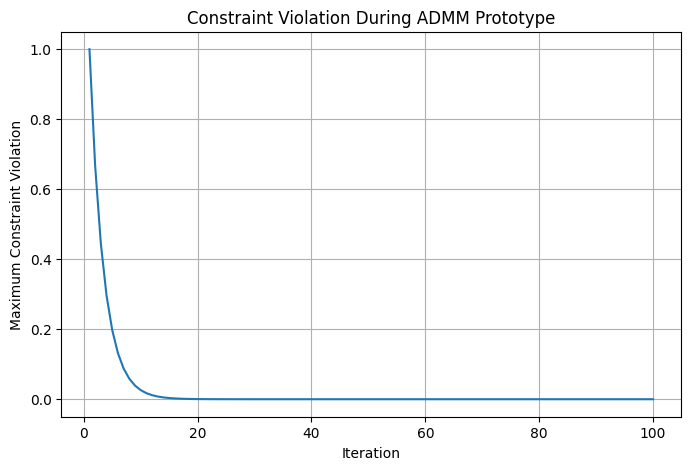

In [116]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(violations) + 1),
    violations
)

plt.xlabel("Iteration")
plt.ylabel("Maximum Constraint Violation")
plt.title("Constraint Violation During ADMM Prototype")
plt.grid(True)

plt.show()

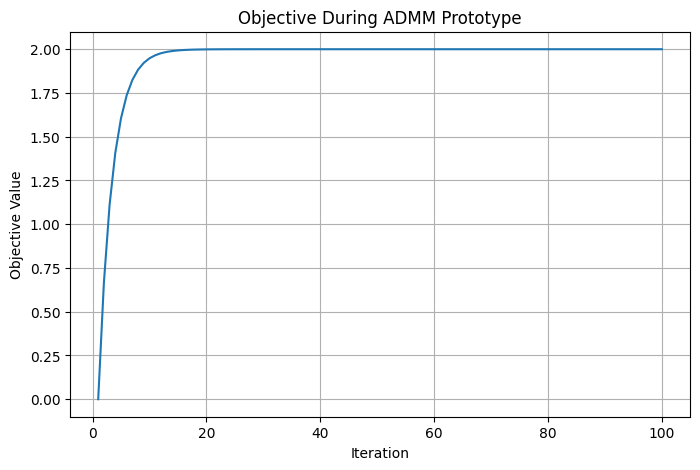

In [117]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(objectives) + 1),
    objectives
)

plt.xlabel("Iteration")
plt.ylabel("Objective Value")
plt.title("Objective During ADMM Prototype")
plt.grid(True)

plt.show()

In [119]:
print("First objective:", objectives[0])
print("Last objective:", objectives[-1])

print("First violation:", violations[0])
print("Last violation:", violations[-1])

print("\nReference objective:", highs_result.fun)
print("ADMM objective:", objectives[-1])

First objective: 0.0
Last objective: 2.0
First violation: 1.0
Last violation: 0.0

Reference objective: 2.0
ADMM objective: 2.0


In [120]:
print("GPU handoff information")
print("------------------------")

print("A shape:", A.shape)
print("A nonzeros:", A.nnz)
print("A format:", A.format)

print("\nOperations needed:")
print("1. A @ x")
print("2. A.T @ y")
print("3. Vector operations")
print("4. Constraint residual calculation")
print("5. Objective calculation")

GPU handoff information
------------------------
A shape: (3443145, 472798)
A nonzeros: 7898666
A format: csr

Operations needed:
1. A @ x
2. A.T @ y
3. Vector operations
4. Constraint residual calculation
5. Objective calculation


In [121]:
x_bench = np.random.rand(A.shape[1])

start = time.perf_counter()

Ax_bench = A @ x_bench

cpu_time = time.perf_counter() - start

print("CPU sparse A @ x time:", cpu_time, "seconds")

CPU sparse A @ x time: 0.02153639984317124 seconds


In [122]:
solver_results = {
    "matrix_shape": A.shape,
    "matrix_nnz": A.nnz,
    "num_variables": len(c),
    "num_constraints": A.shape[0],
    "integer_variables": int(integer_variables),
    "continuous_variables": int(continuous_variables),
    "cpu_sparse_matvec_time": cpu_time
}

with open("aashna_solver_results.pkl", "wb") as f:
    pickle.dump(solver_results, f)

print("Saved: aashna_solver_results.pkl")

Saved: aashna_solver_results.pkl


In [123]:
print("=" * 50)
print("AASHNA SOLVER HANDOFF SUMMARY")
print("=" * 50)

print("Variables:", A.shape[1])
print("Constraints:", A.shape[0])
print("Nonzeros:", A.nnz)

print("Integer/Binary variables:", integer_variables)
print("Continuous variables:", continuous_variables)

print("\nMatrix format:", A.format)

print("\nCPU sparse A @ x:", cpu_time, "seconds")

print("\nFiles ready:")
print("1. presolver_milp_handoff.pkl")
print("2. aashna_solver_results.pkl")

AASHNA SOLVER HANDOFF SUMMARY
Variables: 472798
Constraints: 3443145
Nonzeros: 7898666
Integer/Binary variables: 472009
Continuous variables: 789

Matrix format: csr

CPU sparse A @ x: 0.02153639984317124 seconds

Files ready:
1. presolver_milp_handoff.pkl
2. aashna_solver_results.pkl


In [124]:
def verify_solution(model, solution, objective=None):
    """
    Verify a solution against a generic OptimizationModel.
    """

    Ax = model.A @ solution

    constraint_error = constraint_violation(
        Ax,
        model.constraint_lower,
        model.constraint_upper
    )

    bound_error = bound_violation(
        solution,
        model.variable_lower,
        model.variable_upper
    )

    integer_error = integrality_violation(
        solution,
        model.variable_integrality
    )

    if objective is None:
        objective = model.objective @ solution

    return {
        "objective": float(objective),
        "constraint_violation": float(constraint_error),
        "bound_violation": float(bound_error),
        "integrality_violation": float(integer_error),
        "feasible": (
            constraint_error == 0.0
            and bound_error == 0.0
            and integer_error == 0.0
        )
    }

In [125]:
verification = verify_solution(
    test_model,
    result.solution,
    result.objective
)

print("Verification:")
print("Objective:", verification["objective"])
print("Constraint violation:", verification["constraint_violation"])
print("Bound violation:", verification["bound_violation"])
print("Integrality violation:", verification["integrality_violation"])
print("Feasible:", verification["feasible"])

Verification:
Objective: 2.0
Constraint violation: 0.0
Bound violation: 0.0
Integrality violation: 0.0
Feasible: True


In [131]:
from backend.presolver import GenericPresolver

presolver = GenericPresolver()

presolve_result = presolver.presolve(test_model)

print("Presolve completed")
print("Original variables:", presolve_result.original_variables)
print("Reduced variables:", presolve_result.reduced_variables)
print("Original constraints:", presolve_result.original_constraints)
print("Reduced constraints:", presolve_result.reduced_constraints)
print("Variables removed:", presolve_result.variables_removed)
print("Constraints removed:", presolve_result.constraints_removed)

Presolve completed
Original variables: 2
Reduced variables: 2
Original constraints: 2
Reduced constraints: 2
Variables removed: 0
Constraints removed: 0


In [135]:
import importlib
import backend.presolver

importlib.reload(backend.presolver)

from backend.presolver import GenericPresolver, PresolveResult

In [136]:
presolver = GenericPresolver()

presolve_result = presolver.presolve(test_model)

print("Presolve completed")
print("Fixed variable indices:", presolve_result.fixed_variable_indices)
print("Number of fixed variables:", len(presolve_result.fixed_variable_indices))

Presolve completed
Fixed variable indices: []
Number of fixed variables: 0


In [137]:
fixed_test_model = OptimizationModel(
    A=A_test,
    constraint_lower=lower_test,
    constraint_upper=upper_test,
    objective=c_test,
    variable_lower=np.array([2.0, 0.0]),
    variable_upper=np.array([2.0, 10.0]),
    variable_integrality=integrality_test
)

fixed_presolve = presolver.presolve(fixed_test_model)

print("Fixed-variable test completed")
print("Fixed variable indices:", fixed_presolve.fixed_variable_indices)
print("Number of fixed variables:", len(fixed_presolve.fixed_variable_indices))

Fixed-variable test completed
Fixed variable indices: [np.int64(0)]
Number of fixed variables: 1


In [143]:
import importlib
import backend.solver

importlib.reload(backend.solver)

from backend.solver import ADMMSolver

print("ADMMSolver imported successfully")

ADMMSolver imported successfully


In [144]:
from backend.solver import ADMMSolver

solver = ADMMSolver(
    rho=1.0,
    max_iterations=100
)

result = solver.solve(test_model)

print("Status:", result.status)
print("Solution:", result.solution)
print("Objective:", result.objective)
print("Iterations:", result.iterations)
print("Constraint violation:", result.constraint_violation)
print("Bound violation:", result.bound_violation)
print("Backend:", result.backend)
print("Problem type:", result.problem_type)

Status: FEASIBLE
Solution: [0. 1.]
Objective: 2.0
Iterations: 100
Constraint violation: 0.0
Bound violation: 0.0
Backend: cpu
Problem type: LP


In [145]:
import importlib
import backend.indioptima

importlib.reload(backend.indioptima)

from backend.indioptima import solve

print("IndiOptima solve API imported successfully")

IndiOptima solve API imported successfully


In [146]:
result = solve(test_model)

print("Status:", result.status)
print("Solution:", result.solution)
print("Objective:", result.objective)
print("Iterations:", result.iterations)
print("Constraint violation:", result.constraint_violation)
print("Bound violation:", result.bound_violation)
print("Backend:", result.backend)
print("Problem type:", result.problem_type)

Status: FEASIBLE
Solution: [0. 1.]
Objective: 2.0
Iterations: 100
Constraint violation: 0.0
Bound violation: 0.0
Backend: cpu
Problem type: LP


In [147]:
from backend.mps_parser import MPSParser

parser = MPSParser()

print("MPS parser interface loaded successfully")

MPS parser interface loaded successfully


In [149]:
import importlib
import backend.mps_parser

importlib.reload(backend.mps_parser)

from backend.mps_parser import MPSParser

print("MPS parser module reloaded")

MPS parser module reloaded


In [150]:
parser = MPSParser()

mps_model = parser.parse("../examples/tiny_test.mps")

print("MPS parsed successfully")
print("Variables:", mps_model.n_variables)
print("Constraints:", mps_model.n_constraints)
print("Non-zeros:", mps_model.nnz)
print("Problem type:", mps_model.problem_type)
print("Objective:", mps_model.objective)
print("Constraint lower:", mps_model.constraint_lower)
print("Constraint upper:", mps_model.constraint_upper)
print("Variable lower:", mps_model.variable_lower)
print("Variable upper:", mps_model.variable_upper)

MPS parsed successfully
Variables: 2
Constraints: 2
Non-zeros: 4
Problem type: LP
Objective: [3. 2.]
Constraint lower: [  1. -inf]
Constraint upper: [inf  4.]
Variable lower: [0. 0.]
Variable upper: [10. 10.]


In [151]:
result = solve(mps_model)

print("Status:", result.status)
print("Solution:", result.solution)
print("Objective:", result.objective)
print("Iterations:", result.iterations)
print("Constraint violation:", result.constraint_violation)
print("Bound violation:", result.bound_violation)
print("Backend:", result.backend)
print("Problem type:", result.problem_type)

Status: FEASIBLE
Solution: [0. 1.]
Objective: 2.0
Iterations: 100
Constraint violation: 0.0
Bound violation: 0.0
Backend: cpu
Problem type: LP


In [152]:
import importlib
import backend.mps_parser

importlib.reload(backend.mps_parser)

from backend.mps_parser import MPSParser

print("MPS parser reloaded")

MPS parser reloaded


In [153]:
milp_parser = MPSParser()

milp_model = milp_parser.parse(
    "../examples/tiny_milp.mps"
)

print("MILP parsed successfully")
print("Variables:", milp_model.n_variables)
print("Constraints:", milp_model.n_constraints)
print("Problem type:", milp_model.problem_type)
print("Integrality:", milp_model.variable_integrality)
print("Integer variables:", milp_model.n_integer_variables)
print("Continuous variables:", milp_model.n_continuous_variables)

MILP parsed successfully
Variables: 2
Constraints: 2
Problem type: MILP
Integrality: [1 0]
Integer variables: 1
Continuous variables: 1


In [154]:
import importlib
import backend.mps_parser

importlib.reload(backend.mps_parser)

from backend.mps_parser import MPSParser

milp_parser = MPSParser()
milp_model = milp_parser.parse("../examples/tiny_milp.mps")

print("MILP parsed successfully")
print("Variables:", milp_model.n_variables)
print("Constraints:", milp_model.n_constraints)
print("Problem type:", milp_model.problem_type)
print("Integrality:", milp_model.variable_integrality)
print("Integer variables:", milp_model.n_integer_variables)
print("Continuous variables:", milp_model.n_continuous_variables)

MILP parsed successfully
Variables: 2
Constraints: 2
Problem type: MILP
Integrality: [1 0]
Integer variables: 1
Continuous variables: 1


In [158]:
import importlib

import backend.optimization_model
import backend.mps_parser

# Reload the model first
importlib.reload(backend.optimization_model)

# Then reload the parser so it picks up the new OptimizationModel
importlib.reload(backend.mps_parser)

from backend.mps_parser import MPSParser

# Create a completely new model
milp_parser = MPSParser()
milp_model = milp_parser.parse("../examples/tiny_milp.mps")

print("Model class:", type(milp_model))
print("Summary:", milp_model.summary())

Model class: <class 'backend.optimization_model.OptimizationModel'>
Summary: {'problem_type': 'MILP', 'variables': 2, 'constraints': 2, 'nonzeros': 4, 'integer_variables': 1, 'continuous_variables': 1}


In [159]:
print("Objective:", milp_model.objective)
print("Constraint lower:", milp_model.constraint_lower)
print("Constraint upper:", milp_model.constraint_upper)
print("Variable lower:", milp_model.variable_lower)
print("Variable upper:", milp_model.variable_upper)
print("Integrality:", milp_model.variable_integrality)
print("A:")
print(milp_model.A.toarray())

Objective: [3. 2.]
Constraint lower: [  1. -inf]
Constraint upper: [inf  4.]
Variable lower: [0. 0.]
Variable upper: [10. 10.]
Integrality: [1 0]
A:
[[1. 1.]
 [2. 1.]]


In [160]:
import importlib
import backend.optimization_model
import backend.mps_parser

importlib.reload(backend.optimization_model)
importlib.reload(backend.mps_parser)

from backend.mps_parser import MPSParser

milp_parser = MPSParser()
milp_model = milp_parser.parse("../examples/tiny_milp.mps")

print(milp_model.summary())
print("Integrality:", milp_model.variable_integrality)

{'problem_type': 'MILP', 'variables': 2, 'constraints': 2, 'nonzeros': 4, 'integer_variables': 1, 'continuous_variables': 1}
Integrality: [1 0]


In [163]:
import importlib
import backend.optimization_model
import backend.mps_parser

importlib.reload(backend.optimization_model)
importlib.reload(backend.mps_parser)

from backend.mps_parser import MPSParser

milp_parser = MPSParser()
milp_model = milp_parser.parse("../examples/tiny_milp.mps")

print(milp_model.summary())

{'problem_type': 'MILP', 'variables': 2, 'constraints': 2, 'nonzeros': 4, 'integer_variables': 1, 'continuous_variables': 1, 'objective_sense': 'min'}


In [167]:
import importlib
import backend.optimization_model
import backend.mps_parser

importlib.reload(backend.optimization_model)
importlib.reload(backend.mps_parser)

from backend.mps_parser import MPSParser

parser = MPSParser()
model = parser.parse("../examples/tiny_integer_bounds.mps")

print(model.summary())
print("Lower bounds:", model.variable_lower)
print("Upper bounds:", model.variable_upper)
print("Integrality:", model.variable_integrality)

{'problem_type': 'MILP', 'variables': 2, 'constraints': 1, 'nonzeros': 2, 'integer_variables': 1, 'continuous_variables': 1, 'objective_sense': 'min'}
Lower bounds: [2. 0.]
Upper bounds: [ 8. 10.]
Integrality: [1 0]


In [170]:
import importlib
import backend.benchmark

importlib.reload(backend.benchmark)

from backend.benchmark import run_benchmark

In [171]:
print("LP:")
print(run_benchmark("../examples/tiny_test.mps"))

print("\nMILP:")
print(run_benchmark("../examples/tiny_milp.mps"))

LP:
{'file': '../examples/tiny_test.mps', 'problem_type': 'LP', 'objective_sense': 'min', 'variables': 2, 'constraints': 2, 'nonzeros': 4, 'integer_variables': 0, 'continuous_variables': 2, 'parse_time': 0.0013275146484375, 'solve_time': 0.02866983413696289, 'status': 'FEASIBLE', 'objective': 2.0, 'iterations': 100, 'constraint_violation': 0.0, 'bound_violation': 0.0, 'backend': 'cpu'}

MILP:
{'file': '../examples/tiny_milp.mps', 'problem_type': 'MILP', 'objective_sense': 'min', 'variables': 2, 'constraints': 2, 'nonzeros': 4, 'integer_variables': 1, 'continuous_variables': 1, 'parse_time': 0.00183868408203125, 'solve_time': None, 'status': 'NOT_SUPPORTED', 'message': 'ADMMSolver currently supports LP only. Received: MILP', 'objective': None, 'iterations': None, 'constraint_violation': None, 'bound_violation': None, 'backend': 'cpu'}


In [172]:
import importlib
import backend.indioptima

importlib.reload(backend.indioptima)

<module 'backend.indioptima' from 'c:\\Users\\Manya Aggarwal\\ApexCUDA\\backend\\indioptima.py'>

In [173]:
from backend.mps_parser import MPSParser
from backend.milp_solver import MILPSolver

parser = MPSParser()
model = parser.parse("../examples/tiny_milp.mps")

solver = MILPSolver(max_lp_iterations=100)
result = solver.solve(model)

print("Status:", result.status)
print("Objective:", result.objective)
print("Solution:", result.solution)
print("Problem type:", result.problem_type)

Status: FEASIBLE
Objective: 2.0
Solution: [0. 1.]
Problem type: MILP


In [174]:
from backend.mps_parser import MPSParser
from backend.milp_solver import MILPSolver

parser = MPSParser()
model = parser.parse("../examples/fractional_milp.mps")

print(model.summary())

solver = MILPSolver(max_lp_iterations=100)
result = solver.solve(model)

print("Status:", result.status)
print("Objective:", result.objective)
print("Solution:", result.solution)

{'problem_type': 'MILP', 'variables': 2, 'constraints': 1, 'nonzeros': 2, 'integer_variables': 2, 'continuous_variables': 0, 'objective_sense': 'max'}
Status: FEASIBLE
Objective: 0.0
Solution: [0. 0.]


In [175]:
import importlib
import backend.solver

importlib.reload(backend.solver)

<module 'backend.solver' from 'c:\\Users\\Manya Aggarwal\\ApexCUDA\\backend\\solver.py'>

In [176]:
import backend.milp_solver
importlib.reload(backend.milp_solver)

<module 'backend.milp_solver' from 'c:\\Users\\Manya Aggarwal\\ApexCUDA\\backend\\milp_solver.py'>

In [177]:
from backend.mps_parser import MPSParser
from backend.milp_solver import MILPSolver

parser = MPSParser()
model = parser.parse("../examples/fractional_milp.mps")

solver = MILPSolver(max_lp_iterations=100)
result = solver.solve(model)

print("Status:", result.status)
print("Objective:", result.objective)
print("Solution:", result.solution)

Status: BRANCHING_REQUIRED
Objective: 1.5
Solution: [0.75 0.75]


In [178]:
from backend.mps_parser import MPSParser
from backend.milp_solver import MILPSolver

parser = MPSParser()
model = parser.parse("../examples/fractional_milp.mps")

solver = MILPSolver(
    max_lp_iterations=100,
    max_nodes=100
)

result = solver.solve(model)

print("Status:", result.status)
print("Objective:", result.objective)
print("Solution:", result.solution)
print("Iterations:", result.iterations)
print("Constraint violation:", result.constraint_violation)
print("Bound violation:", result.bound_violation)

Status: BRANCHING_REQUIRED
Objective: 1.5
Solution: [0.75 0.75]
Iterations: 1
Constraint violation: 0.0
Bound violation: 0.0


In [179]:
import importlib
import backend.milp_solver

importlib.reload(backend.milp_solver)

from backend.milp_solver import MILPSolver

In [180]:
from backend.mps_parser import MPSParser

parser = MPSParser()
model = parser.parse("../examples/fractional_milp.mps")

solver = MILPSolver(
    max_lp_iterations=100,
    max_nodes=100
)

result = solver.solve(model)

print("Status:", result.status)
print("Objective:", result.objective)
print("Solution:", result.solution)
print("Iterations:", result.iterations)
print("Constraint violation:", result.constraint_violation)
print("Bound violation:", result.bound_violation)

Status: FEASIBLE
Objective: 1.0
Solution: [0. 1.]
Iterations: 5
Constraint violation: 0.0
Bound violation: 0.0


In [186]:
import inspect
import backend.indioptima

print(inspect.getsource(backend.indioptima.solve))


def solve(model, backend="cpu", rho=1.0, max_iterations=100):
    if backend != "cpu":
        raise NotImplementedError(
            f"Backend '{backend}' is not currently supported."
        )

    presolver = GenericPresolver()
    presolve_result = presolver.presolve(model)

    model = presolve_result.model

    if model.problem_type == "LP":

        solver = ADMMSolver(
            rho=rho,
            max_iterations=max_iterations
        )

    elif model.problem_type == "MILP":

        solver = MILPSolver(
            rho=rho,
            max_lp_iterations=max_iterations
        )

    else:
        raise NotImplementedError(
            f"Problem type '{model.problem_type}' is not currently supported."
        )

    result = solver.solve(model)

    return result



In [187]:
import importlib
importlib.reload(backend.indioptima)

from backend.indioptima import solve

In [188]:
from backend.mps_parser import MPSParser

parser = MPSParser()
model = parser.parse("../examples/fractional_milp.mps")

result = solve(model)

print("Status:", result.status)
print("Objective:", result.objective)
print("Solution:", result.solution)
print("Iterations:", result.iterations)

Status: FEASIBLE
Objective: 1.0
Solution: [0. 1.]
Iterations: 5
